<a href="https://colab.research.google.com/github/alekhyarachapudi/customer-churn-analysis-dashboard/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
df = pd.read_csv("/content/customer_churn_dataset-training-master.csv")
conn=sqlite3.connect('churn.db')
df.to_sql('churn',conn,if_exists='replace',index=False)
print(df.head())

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

In [ ]:
print(df.isnull().sum())

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


In [ ]:
print(df['Churn'].value_counts())

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


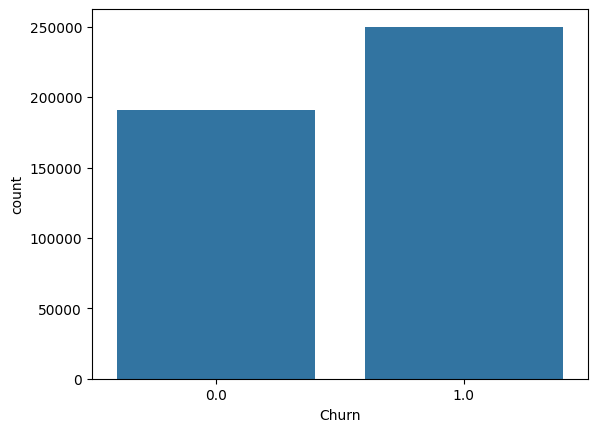

In [ ]:
sns.countplot(x='Churn', data=df)
plt.show()

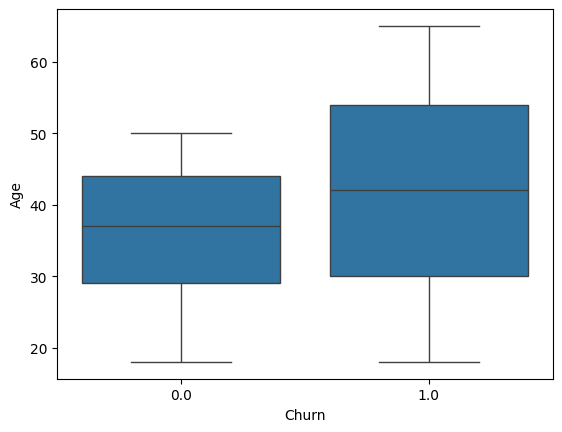

In [ ]:
sns.boxplot(x='Churn', y='Age', data=df)
plt.show()

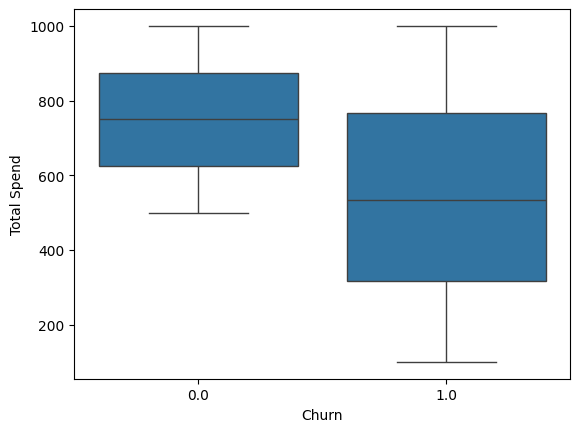

In [ ]:
sns.boxplot(x='Churn', y='Total Spend', data=df)
plt.show()

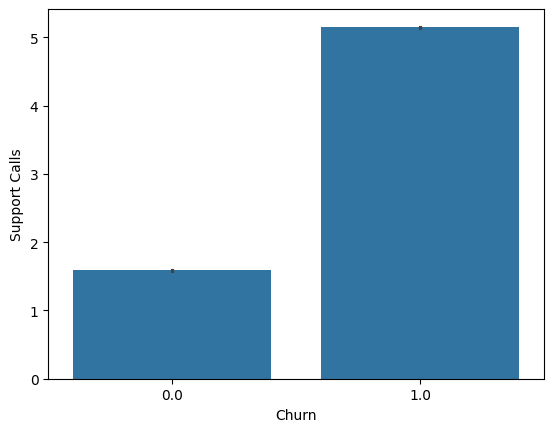

In [ ]:
sns.barplot(x='Churn', y='Support Calls', data=df)
plt.show()

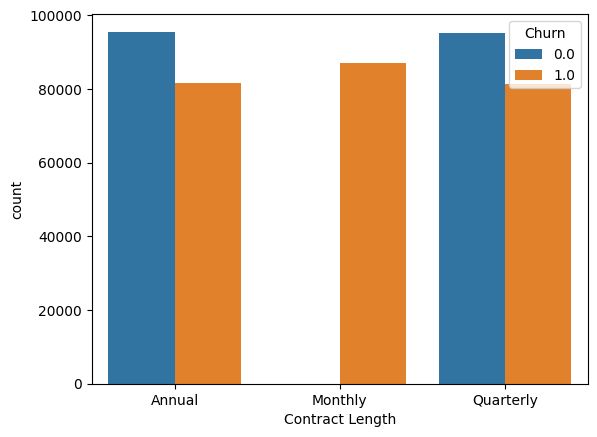

In [ ]:
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.show()

In [ ]:
query="""
SELECT
ROUND(
SUM(CASE WHEN Churn=1 THEN 1 ELSE 0 END)*100.0/COUNT(*),2
) AS churn_percentage
FROM churn;
"""
pd.read_sql(query,conn)

,churn_percentage
0,56.71


In [ ]:
query="""
SELECT 'Subscription_Type', AVG('Total_Spend')
FROM churn
GROUP BY 'Subscription_Type';
"""
pd.read_sql(query,conn)

,'Subscription_Type',AVG('Total_Spend')
0,Subscription_Type,0.0


In [ ]:
query="""
SELECT 'Contract_Length', COUNT(*) AS 'churn_count'
FROM churn
WHERE Churn=1
GROUP BY 'Contract_Length';
"""
pd.read_sql(query,conn)

,'Contract_Length',churn_count
0,Contract_Length,249999
